# Pricing Elasticity & Revenue Intelligence System

## 1. Business Problem

Retail and e-commerce pricing teams need to understand how price, discounts, and marketing
spend relate to demand and revenue so they can make informed pricing decisions. This notebook
walks through a full analysis: from raw transactional data to price-elasticity estimates and a
demand-prediction model.

**Business questions this notebook investigates:**
- How does price relate to quantity sold?
- How do discounts relate to demand?
- How does pricing/elasticity differ across products, categories, regions, and customer segments?
- What are the revenue trends over time?
- Can we build a reasonable statistical/ML model of demand?

> **A note on causality:** This dataset is *observational* (no randomized price experiments were
> run). Everywhere below, relationships are described as **associations / correlations**, not
> proven causal effects, unless a controlled comparison specifically supports a stronger claim.


In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

RAW_PATH = os.path.join('..', 'data', 'raw', 'pricing_transactions.csv')
CLEAN_PATH = os.path.join('..', 'data', 'processed', 'pricing_transactions_clean.csv')
FEATURES_PATH = os.path.join('..', 'data', 'processed', 'pricing_features.csv')


## 2. Dataset

The dataset is **synthetically generated** (`src/generate_data.py`) to resemble a real retail transactions export, complete with missing values, duplicates, outliers, and seasonality. If you have not already generated it, run this from the project root first:

```bash
python src/generate_data.py
```


In [2]:
if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(
        "Raw data not found. Run `python src/generate_data.py` from the project root first."
    )

raw_df = pd.read_csv(RAW_PATH)
print(f"Rows: {len(raw_df):,}  Columns: {raw_df.shape[1]}")
raw_df.head()


Rows: 55,220  Columns: 14


,transaction_id,date,product_id,product_name,category,region,store_id,quantity_sold,unit_price,discount_percentage,revenue,customer_segment,competitor_price,marketing_spend
0,T0048927,2023-05-02,P0029,Beauty Item 29,Beauty & Personal Care,North,S001,40,65.27,0.1088,2326.62,Regular,72.72,NaN
1,T0017803,2022-07-29,P0017,Apparel Item 17,Apparel,East,S011,237,35.29,0.6195,3181.89,VIP,33.74,172.10
2,T0003157,2022-10-22,P0046,Grocery Item 46,Grocery,North,S002,68,31.16,0.1569,1786.58,Budget,28.36,42.08
3,T0001567,2023-02-06,P0042,Grocery Item 42,Grocery,East,S011,41,14.03,0.1329,498.70,Budget,15.00,22.90
4,T0049328,2023-09-25,P0002,Electronics Item 2,Electronics,Central,S016,117,146.24,0.2013,13665.90,Budget,142.79,85.37


## 3. Data Understanding

In [3]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 55220 entries, 0 to 55219
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       55220 non-null  str    
 1   date                 55220 non-null  str    
 2   product_id           55220 non-null  str    
 3   product_name         55220 non-null  str    
 4   category             55220 non-null  str    
 5   region               55220 non-null  str    
 6   store_id             55220 non-null  str    
 7   quantity_sold        55220 non-null  int64  
 8   unit_price           54913 non-null  float64
 9   discount_percentage  54089 non-null  float64
 10  revenue              55220 non-null  float64
 11  customer_segment     55220 non-null  str    
 12  competitor_price     53521 non-null  float64
 13  marketing_spend      53885 non-null  float64
dtypes: float64(5), int64(1), str(8)
memory usage: 5.9 MB


In [4]:
raw_df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,55220,55000,T0003157,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,55220,730,2022-04-23,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,55220,47,P0047,1245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,55220,47,Grocery Item 47,1245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,55220,6,Home & Kitchen,10626,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,55220,5,West,11720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,55220,19,S013,2979,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity_sold,55220.0,NaN,NaN,NaN,116.352046,113.204764,9.0,64.0,105.0,146.0,4044.0
unit_price,54913.0,NaN,NaN,NaN,131.586867,171.246146,-764.56,33.7,68.51,135.4,956.61
discount_percentage,54089.0,NaN,NaN,NaN,0.238313,0.153066,0.0007,0.1216,0.2078,0.3221,0.7


## 4. Data Quality / Validation

We run explicit validation checks before doing any cleaning, so data-quality issues are documented rather than silently patched.

In [5]:
from data_validation import validate, print_report

report = validate(raw_df)
print_report(report)


DATA VALIDATION REPORT
n_rows: 55220
n_duplicate_rows: 218
n_duplicate_transaction_ids: 220

Missing values by column:
  - unit_price: 307
  - discount_percentage: 1131
  - competitor_price: 1699
  - marketing_spend: 1335
negative_unit_price_count: 96
negative_quantity_count: 0
discount_out_of_range_count: 0
quantity_extreme_outliers_iqr_like: 102
unique_products: 47
unique_stores: 19
unique_regions: 5
date_min: 2022-01-01
date_max: 2023-12-31


## 5. Data Preprocessing

Cleaning decisions are documented in `src/data_cleaning.py` (e.g. negative prices are data-entry errors and are corrected; rows missing price are dropped; missing discount is treated as 0; competitor price / marketing spend are imputed with the category median; extreme quantity outliers are winsorized rather than dropped).

In [6]:
from data_cleaning import clean

clean_df = clean(raw_df)
clean_df.to_csv(CLEAN_PATH, index=False)
clean_df.head()


Removed 218 duplicate rows.
Rows after cleaning: 54,696 (from 55,220)


,transaction_id,date,product_id,product_name,category,region,store_id,quantity_sold,unit_price,discount_percentage,revenue,customer_segment,competitor_price,marketing_spend,year,month,day_of_week,is_weekend,quantity_sold_raw
0,T0048927,2023-05-02,P0029,Beauty Item 29,Beauty & Personal Care,North,S001,40.0,65.27,0.1088,2326.74,Regular,72.72,75.15,2023,5,Tuesday,False,40
1,T0017803,2022-07-29,P0017,Apparel Item 17,Apparel,East,S011,237.0,35.29,0.6195,3182.40,VIP,33.74,172.10,2022,7,Friday,False,237
2,T0003157,2022-10-22,P0046,Grocery Item 46,Grocery,North,S002,68.0,31.16,0.1569,1786.43,Budget,28.36,42.08,2022,10,Saturday,True,68
3,T0001567,2023-02-06,P0042,Grocery Item 42,Grocery,East,S011,41.0,14.03,0.1329,498.78,Budget,15.00,22.90,2023,2,Monday,False,41
4,T0049328,2023-09-25,P0002,Electronics Item 2,Electronics,Central,S016,117.0,146.24,0.2013,13665.82,Budget,142.79,85.37,2023,9,Monday,False,117


## 6. Exploratory Data Analysis (EDA)

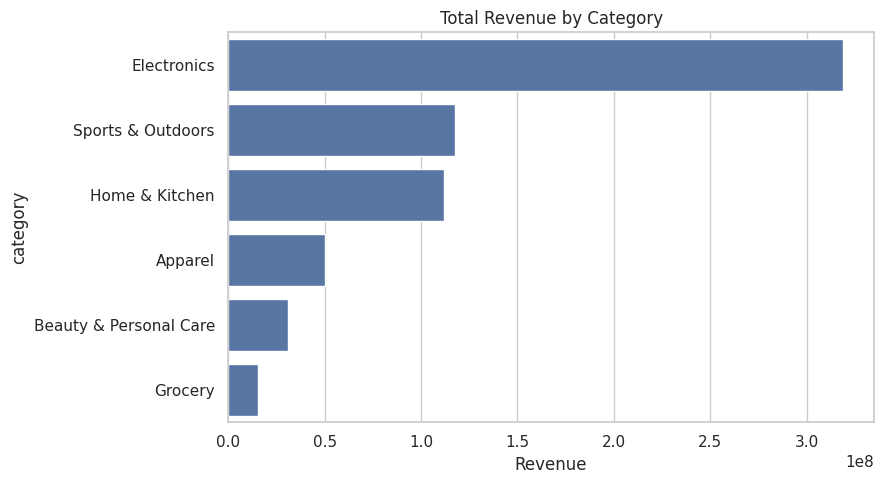

In [7]:
clean_df['date'] = pd.to_datetime(clean_df['date'])

fig, ax = plt.subplots(figsize=(9,5))
rev_by_cat = clean_df.groupby('category')['revenue'].sum().sort_values(ascending=False)
sns.barplot(x=rev_by_cat.values, y=rev_by_cat.index, ax=ax)
ax.set_title('Total Revenue by Category')
ax.set_xlabel('Revenue')
plt.tight_layout()
plt.show()


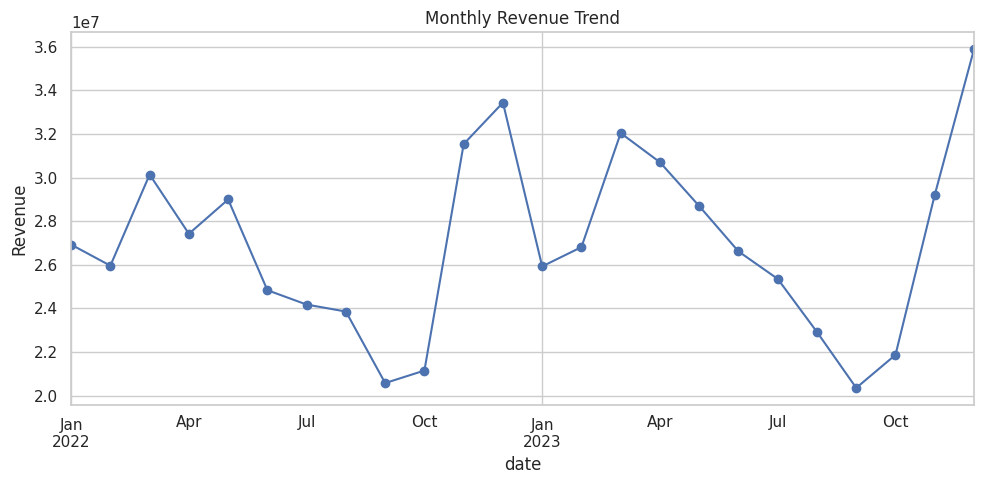

In [8]:
monthly = clean_df.set_index('date').resample('ME')['revenue'].sum()
fig, ax = plt.subplots(figsize=(10,5))
monthly.plot(ax=ax, marker='o')
ax.set_title('Monthly Revenue Trend')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()


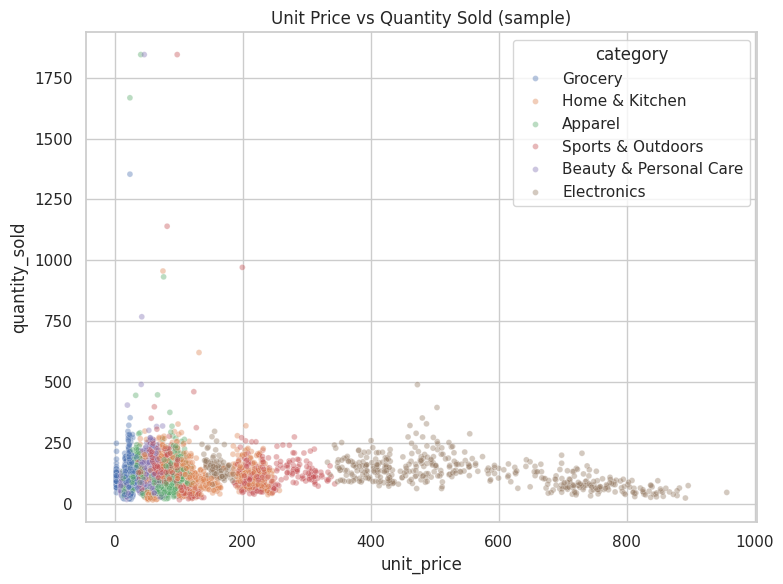

In [9]:
sample = clean_df.sample(min(4000, len(clean_df)), random_state=42)
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=sample, x='unit_price', y='quantity_sold', hue='category', alpha=0.4, s=18, ax=ax)
ax.set_title('Unit Price vs Quantity Sold (sample)')
plt.tight_layout()
plt.show()


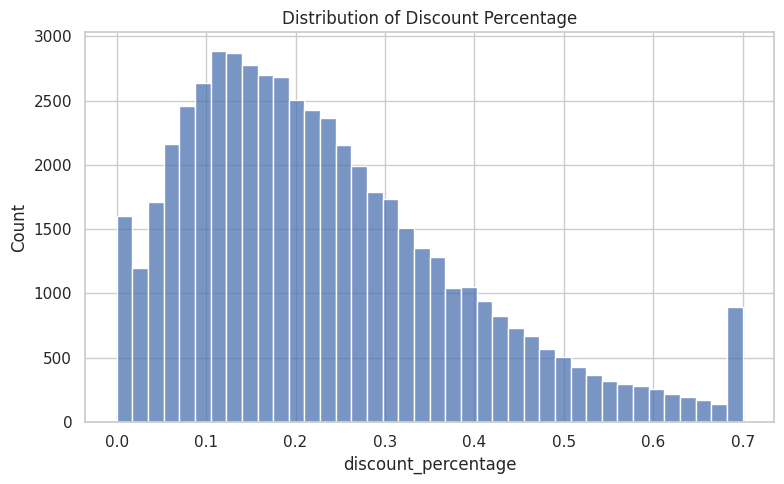

                    count          mean           std     min        25%  \
customer_segment                                                           
Budget            19065.0  11537.407859  19326.565165  108.53  2166.2300   
Premium           10988.0  12281.264908  24495.606155  120.82  2117.4275   
Regular           19147.0  11770.131826  20687.062046  111.38  2165.9800   
VIP                5496.0  11862.369840  22333.445852  132.53  2172.8525   

                      50%        75%        max  
customer_segment                                 
Budget            5142.98  12021.270  583787.25  
Premium           5281.59  12739.545  888382.78  
Regular           5109.27  12327.995  772398.57  
VIP               5359.81  12110.010  672743.73  


In [10]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(clean_df['discount_percentage'], bins=40, ax=ax)
ax.set_title('Distribution of Discount Percentage')
plt.tight_layout()
plt.show()

print(clean_df.groupby('customer_segment')['revenue'].describe())


**Observations:**
- Electronics and Sports & Outdoors contribute disproportionately to revenue relative to their transaction counts, since they carry higher unit prices.
- Revenue shows a clear seasonal uptick around Nov/Dec (holiday promotions) and on weekends.
- Discounting is concentrated in a `0–25%` range with a long right tail during promo months.
- There is a visible negative relationship between price and quantity *within* a given product, but this is much less obvious when looking across all products at once — a first hint that aggregate, cross-product comparisons can be confounded by product mix (see Section 9).

## 7. Statistical Analysis

We use `statsmodels` OLS to quantify statistical relationships. Remember: coefficients describe *association conditional on the included controls*, not a guaranteed causal effect, since prices were not randomly assigned.

In [11]:
from feature_engineering import add_features
from statistical_analysis import run_all_analyses, print_results

feat_df = add_features(clean_df)
feat_df.to_csv(FEATURES_PATH, index=False)

results, _models = run_all_analyses(feat_df)
print_results(results)


log(price) -> log(quantity)  (n=54696, R2=0.125, Adj R2=0.124)
                                       coefficient  std_err   t_value  \
Intercept                                   4.0649   0.0168  241.4793   
C(category)[T.Beauty & Personal Care]       0.0494   0.0083    5.9646   
C(category)[T.Electronics]                  0.2611   0.0118   22.1067   
C(category)[T.Grocery]                      0.1289   0.0090   14.3882   
C(category)[T.Home & Kitchen]               0.1170   0.0081   14.3998   
C(category)[T.Sports & Outdoors]            0.1991   0.0084   23.7009   
C(region)[T.East]                          -0.0132   0.0079   -1.6665   
C(region)[T.North]                         -0.0298   0.0073   -4.0859   
C(region)[T.South]                         -0.0596   0.0073   -8.1794   
C(region)[T.West]                          -0.0836   0.0073  -11.4815   
log_price                                   0.0417   0.0038   10.9868   
discount_percentage                         1.0946   0.0152  

**Interpretation:**
- The `discount -> quantity` model shows a **positive and statistically significant** relationship between discount depth and units sold (as expected).
- The `price -> revenue` model's price coefficient reflects that, on average across the dataset, higher-priced *categories* generate more revenue per transaction — this is heavily influenced by category mix and should not be read as "raising price increases revenue for a given product."
- Check the reported confidence intervals and p-values above for the precision of each estimate before drawing conclusions.

## 8. Feature Engineering

See `src/feature_engineering.py`. Key engineered features: `log_price`, `log_quantity` (for log-log elasticity models), `price_gap_pct` (price vs. competitor), `relative_price_index` (price vs. category average), and discount buckets.

In [12]:
feat_df[['log_price','log_quantity','price_gap_pct','relative_price_index','discount_bucket']].head()


,log_price,log_quantity,price_gap_pct,relative_price_index,discount_bucket
0,4.178533,3.713572,-0.102448,1.472094,medium
1,3.563600,5.472271,0.045940,0.580196,high
2,3.439135,4.234107,0.098731,1.544316,medium
3,2.641198,3.737670,-0.064667,0.695339,medium
4,4.985249,4.770685,0.024161,0.293509,medium


## 9. Price Elasticity Analysis

We estimate price elasticity with a log-log OLS specification: `log(quantity) ~ log(price) + discount`. The coefficient on `log(price)` approximates the percentage change in quantity for a 1% change in price.

We show **two versions**:
1. A naive estimate computed directly on each group (category / region / segment).
2. A version that adds **product fixed effects**, which controls for the fact that different products in the same group have different base prices and base demand levels. This second version is the more defensible estimate whenever a group contains multiple products.

In [13]:
from elasticity_analysis import full_elasticity_report

elasticity_report = full_elasticity_report(feat_df)

print(f"Overall (naive) elasticity: {elasticity_report['overall_elasticity']:.3f} "
      f"-> {elasticity_report['overall_interpretation']}")


Overall (naive) elasticity: 0.080 -> unexpected positive coefficient - interpret with caution


In [14]:
print("Naive elasticity by category (no product controls):")
display(elasticity_report['by_category'].round(3))

print("\nElasticity by category WITH product fixed effects (more defensible):")
display(elasticity_report['by_category_fe'].round(3))


Naive elasticity by category (no product controls):


,category,n_obs,avg_price,avg_quantity,estimated_elasticity
2,Electronics,6980,498.247,137.194,-0.401
5,Sports & Outdoors,9368,137.801,123.328,-0.071
3,Grocery,9227,20.177,111.103,0.007
0,Apparel,10438,60.824,102.055,0.089
4,Home & Kitchen,10532,120.713,120.249,0.128
1,Beauty & Personal Care,8151,44.338,106.726,0.322



Elasticity by category WITH product fixed effects (more defensible):


,category,n_obs,n_products,estimated_elasticity_fe
2,Electronics,6980,6,-1.753
0,Apparel,10438,9,-1.489
5,Sports & Outdoors,9368,8,-1.263
4,Home & Kitchen,10532,9,-1.174
1,Beauty & Personal Care,8151,7,-1.067
3,Grocery,9227,8,-0.682


In [15]:
print("Elasticity by region (FE):")
display(elasticity_report['by_region_fe'].round(3))

print("\nElasticity by customer segment (FE):")
display(elasticity_report['by_segment_fe'].round(3))


Elasticity by region (FE):


,region,n_obs,n_products,estimated_elasticity_fe
2,North,11518,47,-1.311
3,South,11589,47,-1.229
4,West,11613,47,-1.216
0,Central,11512,47,-1.203
1,East,8464,47,-1.188



Elasticity by customer segment (FE):


,customer_segment,n_obs,n_products,estimated_elasticity_fe
0,Budget,19065,47,-1.615
2,Regular,19147,47,-1.193
1,Premium,10988,47,-0.874
3,VIP,5496,47,-0.682


**Key finding:** Once product fixed effects are added, every category/region/segment shows the economically expected **negative** elasticity (demand falls as price rises). The naive, unconditional estimates were confounded by product mix — a concrete illustration of why *correlation across a mixed population is not the same as a controlled comparison*. Budget-segment customers show the most price-sensitive (elastic) demand, and VIP customers the least, which matches typical retail intuition.

## 10. Modeling — Linear Regression for Demand Prediction

Target: `quantity_sold`. We use a **time-based train/test split** (train on earlier dates, test on later ones) since this mirrors how the model would actually be used — predicting future demand from past patterns.

In [16]:
from modeling import train_and_evaluate

model_results = train_and_evaluate(feat_df)


[Baseline (mean predictor)]  MAE=57.039  RMSE=113.643  R2=-0.0000
[Linear Regression]  MAE=49.294  RMSE=107.728  R2=0.1014


## 11. Model Evaluation

Top 10 coefficients by magnitude:


,coefficient
category_Electronics,130.836567
discount_percentage,119.518758
category_Sports & Outdoors,38.440089
relative_price_index,32.986965
category_Home & Kitchen,30.449371
region_West,-11.564373
is_weekend,9.248676
region_South,-6.963276
region_North,-4.430132
region_East,-4.338754


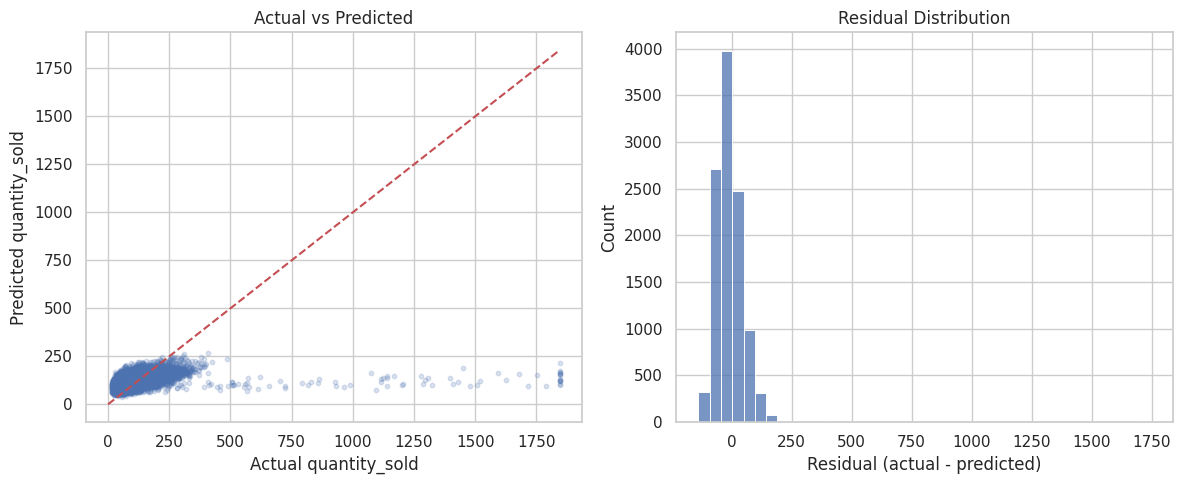

In [17]:
print("Top 10 coefficients by magnitude:")
display(model_results['coefficients'].head(10))

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(model_results['y_test'], model_results['y_pred'], alpha=0.2, s=10)
lims = [0, max(model_results['y_test'].max(), model_results['y_pred'].max())]
ax[0].plot(lims, lims, 'r--')
ax[0].set_xlabel('Actual quantity_sold')
ax[0].set_ylabel('Predicted quantity_sold')
ax[0].set_title('Actual vs Predicted')

sns.histplot(model_results['residuals'], bins=40, ax=ax[1])
ax[1].set_title('Residual Distribution')
ax[1].set_xlabel('Residual (actual - predicted)')
plt.tight_layout()
plt.show()


**Evaluation notes:**
- We compare against a naive baseline (always predicting the training-set mean). The linear model reduces RMSE relative to that baseline — see the printed percentage improvement above.
- `R²` is modest, which is realistic: demand here is generated with a Poisson noise process, occasional bulk-order outliers, and several unobserved effects, so a *linear* model is not expected to explain all of the variance. A modest R² with correctly-signed, significant coefficients is more trustworthy than an overfit model with suspiciously high R².
- We use MAE/RMSE/R² because this is a regression problem — accuracy is not an appropriate metric here.

## 12. Business Interpretation / Key Findings

1. **Discounting reliably increases unit volume** (`discount -> quantity` is positive and significant), but at the cost of revenue per unit — the `price -> revenue` and `marketing -> revenue` models suggest a trade-off worth quantifying per product before running blanket promotions.
2. **Price elasticity varies meaningfully across categories and segments.** Once product mix is controlled for (fixed-effects estimates), Electronics and Apparel show the most elastic (price-sensitive) demand, while Grocery is comparatively inelastic. Budget-segment customers are the most price sensitive, VIP customers the least.
3. **Revenue is seasonal**, with a pronounced November/December uplift — useful for inventory and marketing-spend planning.
4. **A simple linear demand model provides a modest but real improvement over a naive baseline**, useful as a first-pass planning tool, not a precision forecasting system.

## Dashboards

Four dashboards are built with Matplotlib/Seaborn by `src/generate_dashboard.py` and saved to `dashboard/` together with a self-contained `pricing_dashboard.html` you can open in any browser. Filters are available from the command line (e.g. `python src/generate_dashboard.py --region North --year 2023`).

Saved 4 dashboards + HTML report (All data) -> /home/claude/build/P1/Pricing_Elasticity_Revenue_Intelligence/src/../dashboard


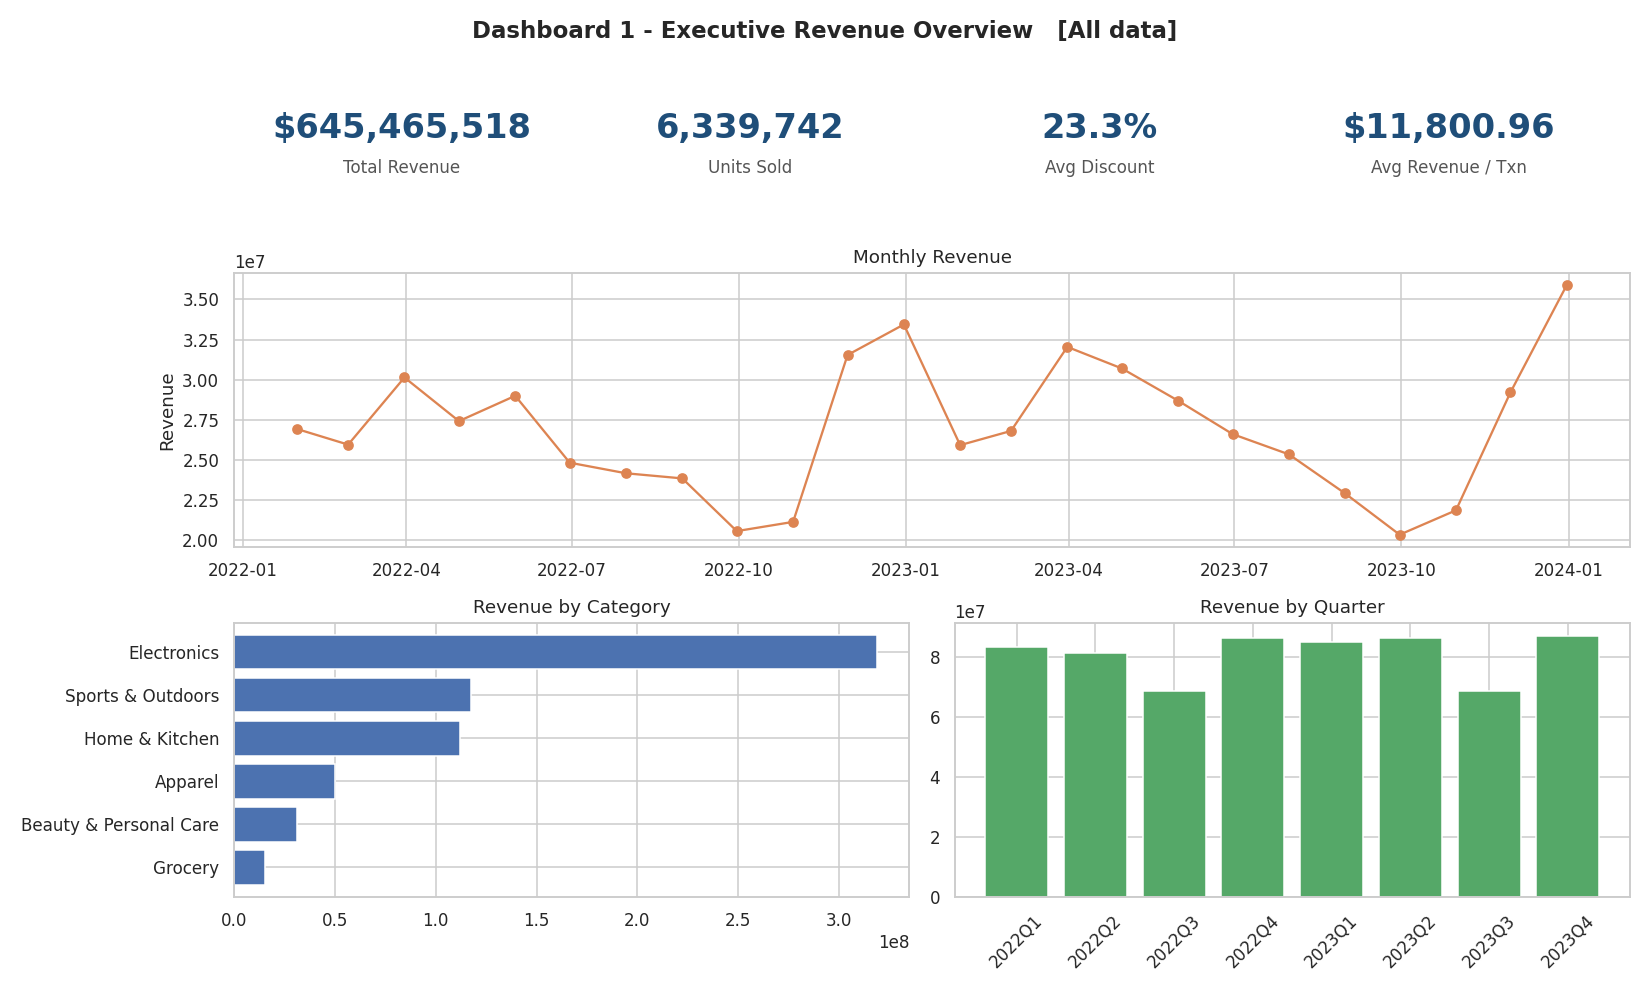

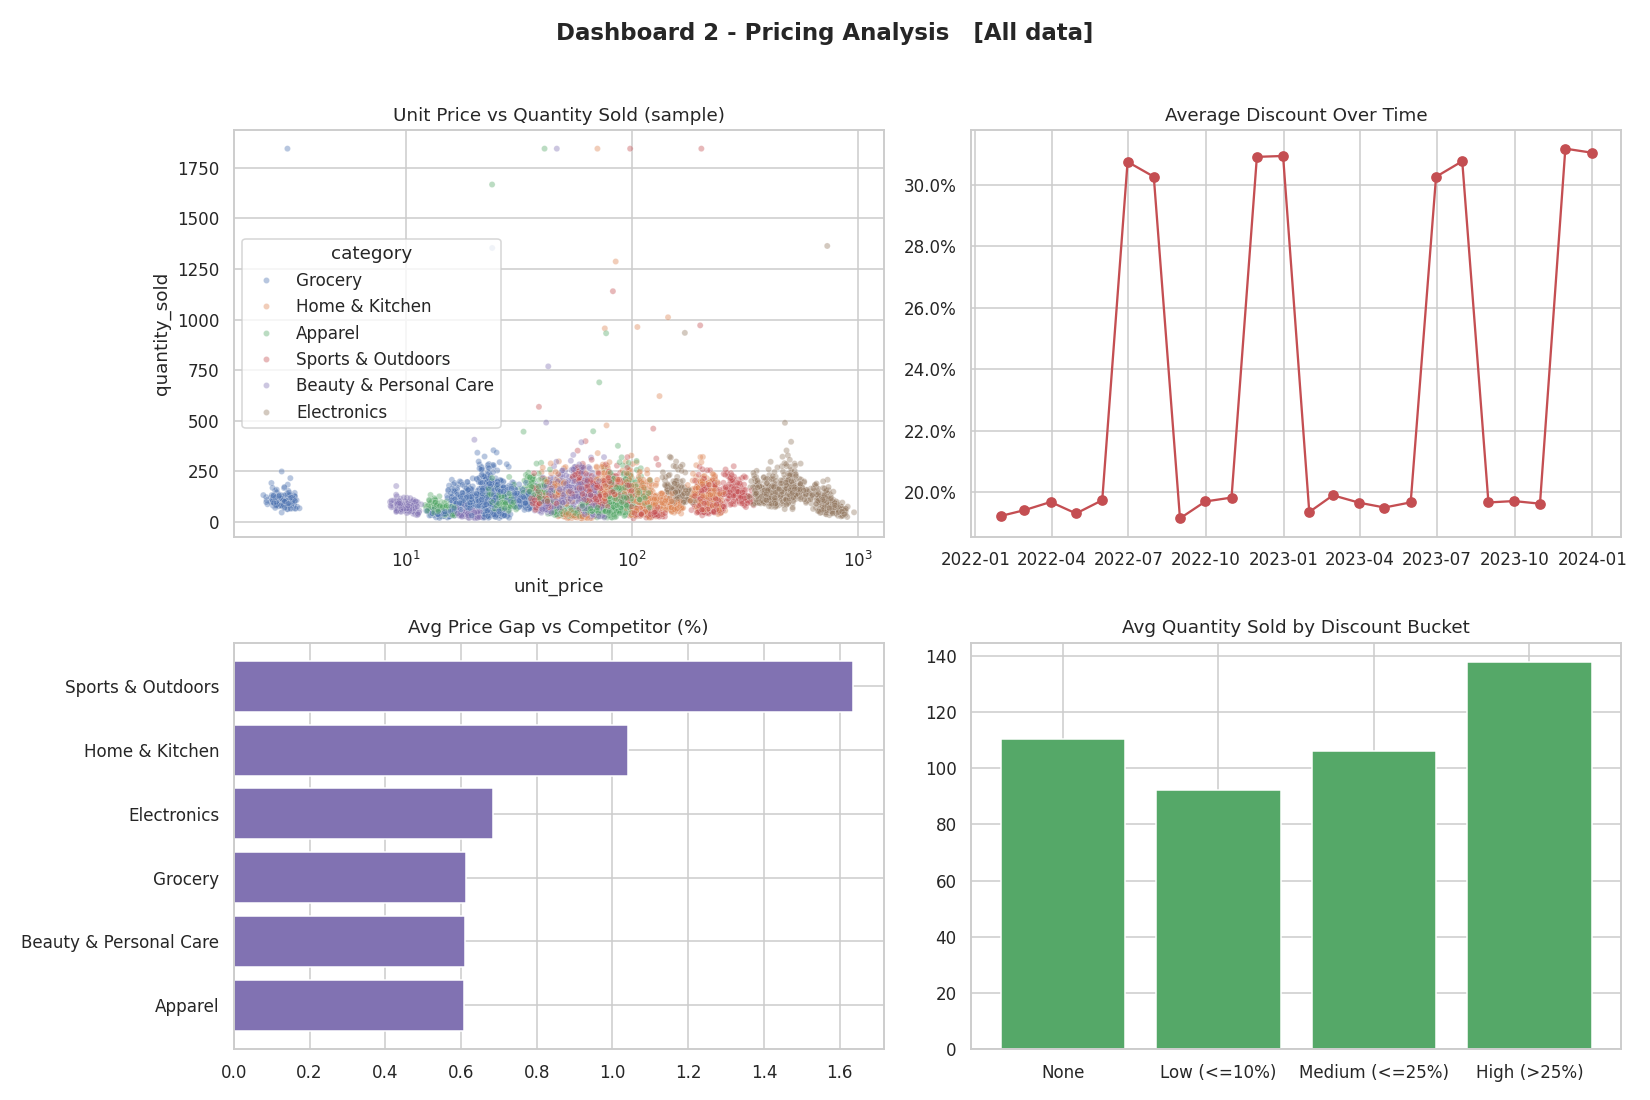

In [18]:
import subprocess, sys
from IPython.display import Image, display

subprocess.run([sys.executable, os.path.join('..', 'src', 'generate_dashboard.py')], check=True)
display(Image(os.path.join('..', 'dashboard', 'dashboard_1_executive_revenue.png')))
display(Image(os.path.join('..', 'dashboard', 'dashboard_2_pricing_analysis.png')))


## 13. Limitations & Conclusion

**Limitations:**
- This is a **synthetic** dataset; absolute elasticity values and coefficients should not be treated as real-world figures — the *methodology* is the transferable part.
- Price variation in this dataset is not the result of a randomized experiment, so even the fixed-effects elasticity estimates reflect *statistical association*, not a proven causal effect. A true causal estimate would require a designed price experiment or a quasi-experimental method (e.g. instrumental variables, regression discontinuity).
- The linear regression model assumes linear relationships and does not capture potential non-linear or interaction effects (e.g. diminishing returns to marketing spend).
- Outliers were winsorized rather than modeled explicitly; a more advanced approach could model bulk/wholesale orders separately.

**Conclusion:** This notebook demonstrates a complete, defensible pricing-analytics workflow: data validation and cleaning, EDA, statistically grounded elasticity estimation (including a worked example of controlling for confounding), and a baseline demand-prediction model, with findings translated into business-relevant language.

See `README.md` for the dashboard details and interview preparation notes.